# Random Forest - Experiments

This notebook demonstrates how to use the Random Forest pipeline for predicting match outcomes between two teams, following the same structure as the XGBoost model.

## 1. Setup and Imports

In [ ]:
import sys

sys.path.append("..")

import pandas as pd

from src.dataloaders.simple import SeasonAverageDataLoader
from src.experiments import DefaultTracker, ExperimentConfig
from src.experiments.config import RunConfig
from src.models.randomforest import RandomForestHyperparamConfig, RandomForestRegressorModel
from src.submissions import create_submission, generate_matchups

c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because

## 2. Configure the Random Forest Model

Set hyperparameters for the Random Forest model:

In [ ]:
# Random Forest hyperparameters
rf_params = RandomForestHyperparamConfig(
    n_estimators=400,  # Number of trees in the forest
    max_depth=6,  # Maximum depth of trees
    min_samples_split=2,  # Minimum samples required to split a node
    min_samples_leaf=1,  # Minimum samples required at leaf node
    max_features="sqrt",  # Number of features to consider for best split
    max_samples=0.8,  # Fraction of samples to use for each tree
    bootstrap=True,  # Whether to use bootstrap samples
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
)

# Run configuration
run_config = RunConfig(
    num_features=20,  # Number of top features to use
    valid_season=2024,  # Season to validate on
    start_season=2003,  # First season to train on
    data_loader="season_average",
)

## 3. Initialize Data Loader and Model

In [3]:
data_loader = SeasonAverageDataLoader(num_features=run_config.num_features)

experiment_config = ExperimentConfig(name="random-forest", project="random-forest")
tracker = DefaultTracker(experiment_config)

rf_model = RandomForestRegressorModel(data=data_loader, params=rf_params, cv=None, tracker=tracker)

## 4. Train the Model


In [4]:
rf_model.fit(season=run_config.valid_season, start_season=run_config.start_season)

metrics: {'train_brier': np.float64(0.14466579846696406)}, step: None


## 5. Validate the Model

Evaluate model performance on the validation season:

In [5]:
rf_model.validate()

metrics: {'valid_brier': np.float64(0.16080381763257576)}, step: None


## 6. Make Predictions

Generate predictions for tournament matchups:

In [6]:
season = 2025
matchups = generate_matchups(season)

print(f"Generated {len(matchups)} matchups for season {season}")
print("\nSample matchups:")
print(matchups.head())

Generated 131407 matchups for season 2025

Sample matchups:
   LowerID  HigherID              ID
0     1101      1102  2025_1101_1102
1     1101      1103  2025_1101_1103
2     1101      1104  2025_1101_1104
3     1101      1105  2025_1101_1105
4     1101      1106  2025_1101_1106


In [7]:
predictions = rf_model.predict(matchups)

print("\nSample predictions:")
print(predictions.head(10))
print("\nPrediction statistics:")
print(f"Mean: {predictions.mean():.4f}")
print(f"Std: {predictions.std():.4f}")
print(f"Min: {predictions.min():.4f}")
print(f"Max: {predictions.max():.4f}")


Sample predictions:
0    0.551297
1    0.353951
2    0.046147
3    0.625079
4    0.501013
5    0.529704
6    0.599592
7    0.491343
8    0.448200
9    0.089589
dtype: float64

Prediction statistics:
Mean: 0.5025
Std: 0.2013
Min: 0.0244
Max: 0.9777


## 7. Create Submission File

In [12]:
submission = create_submission(
    season=season, model=rf_model, filename=f"submission_randomforest_season_{season}.csv", fit=True
)

metrics: {'train_brier': np.float64(0.14506149453959744)}, step: None


## 8. Feature Importance (Optional)

Analyze which features are most important for the Random Forest model:


Top 10 Most Important Features:
                   feature  importance
0              QualityDiff    0.287504
1                 SeedDiff    0.169738
3                   T2_Elo    0.099400
2                   T1_Elo    0.092818
5               T2_avg_Elo    0.084049
4               T1_avg_Elo    0.072366
7               T2_avg_Blk    0.018019
15  T1_avg_opponent_Streak    0.016647
6               T1_avg_Blk    0.016476
17              T1_avg_Ast    0.016399


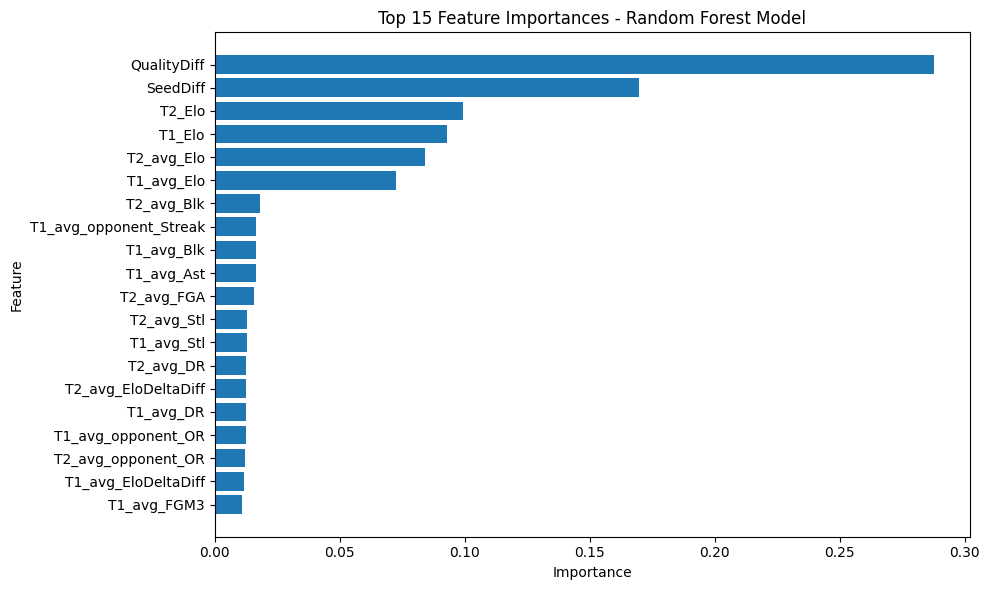

In [11]:
import matplotlib.pyplot as plt

feature_names = data_loader.features[: run_config.num_features]
importances = rf_model.model.feature_importances_

# Create a DataFrame for easier analysis
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"].head(25), importance_df["importance"].head(25))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()